<a href="https://colab.research.google.com/github/gonzalopezgil/xlstm-ts/blob/fix/leakage-safe-denoising/notebooks/sp500_daily.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Leakage-Safe xLSTM-TS Time Series Movement Prediction

**Notebook 1: S&P 500 - Daily Close Prices**

---

> **Correction notice (May 2026):** Issue #2 identified leakage in the original wavelet-denoising workflow. This notebook now uses the leakage-safe branch, causal `wavelet_denoising()`, and train-only scaling. The old cached offline-denoised daily xLSTM-TS result (`66.22%` test accuracy, `68.33%` F1) is deprecated and must not be cited as live forecasting performance. A bounded Colab T4 rerun on this branch produced raw xLSTM-TS `49.20%` test accuracy / `51.40%` F1 and causal-denoised-feature xLSTM-TS `47.87%` test accuracy / `49.74%` F1.


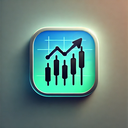

**Note**: Run with T4 GPU in Google Colab! (CUDA is required)

## Constants

**Dataset**: S&P 500 (US)

https://finance.yahoo.com/quote/%5EGSPC/

In [ ]:
# Ticker (check in Yahoo Finance) and custom stock name
TICKER = '^GSPC' # S&P 500 index
STOCK = 'S&P 500'

# Date range (YYYY-MM-DD) and frequency
START_DATE = '2000-01-01'
END_DATE = '2023-12-31'
FREQ = '1d' # daily frequency

FILE_NAME = 'sp500_daily' # custom file name

*   **Train**: 01/2000 - 12/2020
*   **Validation**: 01/2021 - 06/2022
*   **Test**: 07/2022 - 12/2023

In [ ]:
# Train, validation, test split
TRAIN_END_DATE = '2021-01-01'
VAL_END_DATE = '2022-07-01'

## Requirements

In [ ]:
import os

repo_url = 'https://github.com/gonzalopezgil/xlstm-ts.git'
repo_branch = 'fix/leakage-safe-denoising'
repo_dir = 'xlstm-ts'

if os.path.isdir(repo_dir):
    !git -C {repo_dir} fetch origin {repo_branch}
    !git -C {repo_dir} checkout {repo_branch}
    !git -C {repo_dir} pull --ff-only origin {repo_branch}
else:
    !git clone --branch {repo_branch} --single-branch {repo_url}


In [ ]:
%cd xlstm-ts

NOTE: It can take a few minutes to install all dependencies.

In [ ]:
requirements_marker = '/content/.xlstm_ts_requirements_installed'

if os.path.exists(requirements_marker):
    print('Dependencies already installed in this Colab VM; skipping pip install.')
else:
    !pip install -r requirements.txt --quiet
    with open(requirements_marker, 'w') as marker_file:
        marker_file.write('installed\n')
    print('Dependencies installed. If Colab reports a NumPy/Pandas binary mismatch, restart the runtime once and rerun all cells.')


In [ ]:
# Add the src directory to the Python path
import sys
import os

# Get the path of the current working directory
current_dir = os.getcwd()

# Construct the path to the 'src' directory in the current folder
src_path = os.path.join(current_dir, 'src')

# Add the 'src' directory to the Python path
if src_path not in sys.path:
    sys.path.append(src_path)

In [ ]:
from ml.utils.imports import *

### Optional: Retrieve MORE hourly data (API limitations apply)

(SKIP THIS STEP IF YOU DO NOT NEED HOURLY DATA MORE THAN 2 YEARS OLD)

**Where to find your Tiingo API Token?**

**Step 1: Create a Tiingo account if you have not already.**

You can do so by visit https://api.tiingo.com and clicking “Sign-up” in the top right corner.

**Step 2: Access the API Token Account Page.**

Visit https://api.tiingo.com/account/api/token to see your API Token and copy it below. Do not share it with anybody as this token will identify your usage with your account.

In [ ]:
os.environ['TIINGO_API_KEY'] = '' # Add your Tiingo API key here

## Dataset

In [ ]:
from ml.data.download import download_data
from ml.utils.visualisation import plot_data

### **Optional: Read local files**

If you want to read the given data from the experiment, UNCOMMENT this code snippet and COMMENT OUT the regular download to proceed.

(NOTE: The regular download will retrieve the exact same data by default, you can experiment with the constants at the top of the file to change it)

In [ ]:
'''
# Read the CSV file and set the "Date" column as the index
file_path = os.path.join('data', 'datasets', FILE_NAME + '.csv')
df = pd.read_csv(file_path, header=0, index_col='Date')
# Convert the index to a datetime object
df.index = df.index.to_series().apply(lambda x: datetime.datetime.strptime(x, "%Y-%m-%d %H:%M:%S%z"))
'''

### Download data

- **Tiingo**: If the frequency is hourly and the starting date is more than 2 years before, the Tiingo API will be used. You need to enter the API key to proceed (the steps are explained above). Note that restrictive API limitations apply.

- **Yahoo Finance**: In all other cases, Yahoo Finance will be used. There's no need to enter an API key to download data from it, and there are no API restrictions with responsible usage.

In [ ]:
# Load the bundled experiment dataset when available. This keeps reruns
# reproducible and avoids transient Yahoo Finance download failures.
file_path = os.path.join('data', 'datasets', FILE_NAME + '.csv')

if os.path.exists(file_path):
    df = pd.read_csv(file_path, header=0, index_col='Date')
    date_index = pd.Index(df.index.astype(str)).str.slice(0, 19)
    df.index = pd.to_datetime(date_index)
else:
    df = download_data(ticker=TICKER, start_date=START_DATE, end_date=END_DATE, freq=FREQ)

if df.empty:
    raise ValueError(f'No data loaded for {FILE_NAME}. Check the bundled dataset or download source.')

# Plot the raw data
plot_data(df, STOCK)


## Preprocessing

### Causal wavelet denoising

Reference: https://doi.org/10.1002/for.3071

`wavelet_denoising()` is causal in this branch: the value at timestamp `t` is computed only from observations available at or before `t`. The legacy full-series smoother is `offline_wavelet_denoising()` and is for offline visual analysis only, not forecasting metrics.

In [ ]:
from ml.data.preprocessing import wavelet_denoising, plot_wavelet_denoising

In [ ]:
# Apply leakage-safe causal denoising.
# Each Close_denoised[t] is computed only from Close[:t + 1].
df['Close_denoised'] = wavelet_denoising(df['Close'])
df['Noise'] = df['Close'] - df['Close_denoised']

plot_wavelet_denoising(df, STOCK)

### Process dates

In [ ]:
from ml.data.preprocessing import process_dates

In [ ]:
# Convert the Date column to time zone-naive datetime
df = process_dates(df)

### Model-specific preprocessing

#### For darts library models

##### Convert to darts TimeSeries

**Darts Library**:

- Paper: https://www.jmlr.org/papers/v23/21-1177.html
- Documentation: https://unit8co.github.io/darts/README.html#
- Repository: https://github.com/unit8co/darts

In [ ]:
from ml.models.darts.preprocessing import convert_to_ts_daily

In [ ]:
series, series_denoised = convert_to_ts_daily(df)
series_denoised

##### Causal denoised input with raw-price evaluation

In [ ]:
from ml.models.darts.preprocessing import split_train_val_test_darts

In [ ]:
# Transform the string dates into datetime objects
TRAIN_END_DATE = datetime.datetime.strptime(TRAIN_END_DATE, '%Y-%m-%d')
VAL_END_DATE = datetime.datetime.strptime(VAL_END_DATE, '%Y-%m-%d')

In [ ]:
train, val, test = split_train_val_test_darts(series, TRAIN_END_DATE, VAL_END_DATE)
train_denoised, val_denoised, test_denoised = split_train_val_test_darts(series_denoised, TRAIN_END_DATE, VAL_END_DATE)

In [ ]:
train_denoised.plot(label="train");
val_denoised.plot(label="val");
test_denoised.plot(label="test");

##### Create raw-target sequences

In [ ]:
from ml.models.darts.preprocessing import normalise_split_data_darts

In [ ]:
train, val, test, scaler_darts = normalise_split_data_darts(train, val, test)
train_denoised, val_denoised, test_denoised, scaler_darts_denoised = normalise_split_data_darts(train_denoised, val_denoised, test_denoised)

#### For the proposed model

##### Create raw-target sequences

In [ ]:
from ml.models.xlstm_ts.preprocessing import (
    create_feature_target_sequences,
    normalise_feature_target_split_data_xlstm,
    split_train_val_test_xlstm,
)

In [ ]:
X, y, dates = create_feature_target_sequences(
    df['Close'].values.reshape(-1, 1),
    df['Close'].values.reshape(-1, 1),
    df.index,
)

In [ ]:
X_denoised, y_denoised, dates_denoised = create_feature_target_sequences(
    df['Close_denoised'].values.reshape(-1, 1),
    df['Close'].values.reshape(-1, 1),
    df.index,
)

##### Split and scale after splitting

In [ ]:
train_X, train_y, train_dates, val_X, val_y, val_dates, test_X, test_y, test_dates = split_train_val_test_xlstm(
    X,
    y,
    dates,
    TRAIN_END_DATE,
    VAL_END_DATE,
)

In [ ]:
train_X, train_y, val_X, val_y, test_X, test_y, feature_scaler, scaler = normalise_feature_target_split_data_xlstm(
    train_X,
    train_y,
    val_X,
    val_y,
    test_X,
    test_y,
)

In [ ]:
train_X_denoised, train_y_denoised, train_dates_denoised, val_X_denoised, val_y_denoised, val_dates_denoised, test_X_denoised, test_y_denoised, test_dates_denoised = split_train_val_test_xlstm(
    X_denoised,
    y_denoised,
    dates_denoised,
    TRAIN_END_DATE,
    VAL_END_DATE,
)

##### Causal denoised input with raw-price evaluation

In [ ]:
train_X_denoised, train_y_denoised, val_X_denoised, val_y_denoised, test_X_denoised, test_y_denoised, feature_scaler_denoised, scaler_denoised = normalise_feature_target_split_data_xlstm(
    train_X_denoised,
    train_y_denoised,
    val_X_denoised,
    val_y_denoised,
    test_X_denoised,
    test_y_denoised,
)

## Models

In [ ]:
from ml.models.shared.directional_prediction import *
from ml.models.shared.metrics import *
from ml.models.shared.visualisation import *
from ml.models.darts.darts_models import *
from ml.models.darts.training import *

In [ ]:
metrics_accumulator = {}
metrics_accumulator_denoised = {}

### TCN

**References**:

- Paper (2018): https://doi.org/10.48550/arXiv.1803.01271
- Code: https://github.com/unit8co/darts/blob/master/darts/models/forecasting/tcn_model.py
- Darts documentation: https://unit8co.github.io/darts/examples/05-TCN-examples.html

**Not denoised**

In [ ]:
model = get_model_tcn()
metrics_accumulator[model.model_name] = training_darts(model, train, val, test, scaler_darts, STOCK, "Original")

**Causal denoised input with raw-price evaluation**

In [ ]:
model = get_model_tcn()
metrics_accumulator_denoised[model.model_name] = training_darts(model, train, val, test, scaler_darts, STOCK, "Causal Denoised", train_denoised, val_denoised, test_denoised, scaler_darts_denoised)

### DeepTCN

**References**:

- Paper (2020): https://doi.org/10.48550/arXiv.1906.04397
- Code (same as TCN): https://github.com/unit8co/darts/blob/master/darts/models/forecasting/tcn_model.py
- Darts documentation: https://unit8co.github.io/darts/examples/09-DeepTCN-examples.html

**Not denoised**

In [ ]:
model = get_model_deeptcn()
metrics_accumulator[model.model_name] = training_darts(model, train, val, test, scaler_darts, STOCK, "Original")

**Causal denoised input with raw-price evaluation**

In [ ]:
model = get_model_deeptcn()
metrics_accumulator_denoised[model.model_name] = training_darts(model, train, val, test, scaler_darts, STOCK, "Causal Denoised", train_denoised, val_denoised, test_denoised, scaler_darts_denoised)

### N-BEATS

**References**:
- Paper (2020): https://doi.org/10.48550/arXiv.1905.10437
- Code: https://github.com/unit8co/darts/blob/master/darts/models/forecasting/nbeats.py
- Darts documentation: https://unit8co.github.io/darts/examples/07-NBEATS-examples.html

**Not denoised**

In [ ]:
model = get_model_nbeats()
metrics_accumulator[model.model_name] = training_darts(model, train, val, test, scaler_darts, STOCK, "Original")

**Causal denoised input with raw-price evaluation**

In [ ]:
model = get_model_nbeats()
metrics_accumulator_denoised[model.model_name] = training_darts(model, train, val, test, scaler_darts, STOCK, "Causal Denoised", train_denoised, val_denoised, test_denoised, scaler_darts_denoised)

### TFT

Temporal Fusion Transformer Model

**References**:

- Paper (2021): https://doi.org/10.1016/j.ijforecast.2021.03.012
- Code: https://github.com/unit8co/darts/blob/master/darts/models/forecasting/tft_model.py
- Darts documentation: https://unit8co.github.io/darts/examples/13-TFT-examples.html

**Not denoised**

In [ ]:
model = get_model_tft()
metrics_accumulator[model.model_name] = training_darts(model, train, val, test, scaler_darts, STOCK, "Original")

**Causal denoised input with raw-price evaluation**

In [ ]:
model = get_model_tft()
metrics_accumulator_denoised[model.model_name] = training_darts(model, train, val, test, scaler_darts, STOCK, "Causal Denoised", train_denoised, val_denoised, test_denoised, scaler_darts_denoised)

### TiDE

TimeSeries Dense Encoder Model

**References**:
- Paper (2024): https://doi.org/10.48550/arXiv.2304.08424
- Code: https://github.com/unit8co/darts/blob/master/darts/models/forecasting/tide_model.py
- Darts documentation: https://unit8co.github.io/darts/examples/18-TiDE-examples.html

**+RIN**

Reversible Instance Normalization for Accurate Time-Series Forecasting against Distribution Shift

- Paper: https://openreview.net/forum?id=cGDAkQo1C0p

**Not denoised**

In [ ]:
model = get_model_tide()
metrics_accumulator[model.model_name] = training_darts(model, train, val, test, scaler_darts, STOCK, "Original")

**Causal denoised input with raw-price evaluation**

In [ ]:
model = get_model_tide()
metrics_accumulator_denoised[model.model_name] = training_darts(model, train, val, test, scaler_darts, STOCK, "Causal Denoised", train_denoised, val_denoised, test_denoised, scaler_darts_denoised)

### N-HiTS

**Neural Hierarchical Interpolation for Time Series Forecasting**

References:

- Paper (2022): https://doi.org/10.48550/arXiv.2201.12886
- Code: https://github.com/unit8co/darts/blob/master/darts/models/forecasting/nhits.py
- Darts documentation: https://unit8co.github.io/darts/examples/18-TiDE-examples.html

**Not denoised**

In [ ]:
model = get_model_nhits()
metrics_accumulator[model.model_name] = training_darts(model, train, val, test, scaler_darts, STOCK, "Original")

**Causal denoised input with raw-price evaluation**

In [ ]:
model = get_model_nhits()
metrics_accumulator_denoised[model.model_name] = training_darts(model, train, val, test, scaler_darts, STOCK, "Causal Denoised", train_denoised, val_denoised, test_denoised, scaler_darts_denoised)

### TSMixer

TimeSeries Mixer Model

**References**:
- Paper (2023): https://doi.org/10.48550/arXiv.2303.06053
- Code: https://github.com/ditschuk/pytorch-tsmixer
- Darts documentation: https://unit8co.github.io/darts/examples/21-TSMixer-examples.html

**Not denoised**

In [ ]:
model = get_model_tsm()
metrics_accumulator[model.model_name] = training_darts(model, train, val, test, scaler_darts, STOCK, "Original")

**Causal denoised input with raw-price evaluation**

In [ ]:
model = get_model_tsm()
metrics_accumulator_denoised[model.model_name] = training_darts(model, train, val, test, scaler_darts, STOCK, "Causal Denoised", train_denoised, val_denoised, test_denoised, scaler_darts_denoised)

### New proposed model: xLSTM-TS, a time series-specific implementation

**References:**

- xLSTM Paper (2024): https://doi.org/10.48550/arXiv.2405.04517

- Official code: https://github.com/NX-AI/xlstm

- Parameters for time series: https://github.com/smvorwerk/xlstm-cuda

#### Configuration

In [ ]:
from ml.models.xlstm_ts.xlstm_ts_model import *
from ml.models.xlstm_ts.logic import *

In [ ]:
plot_architecture_xlstm()

#### Training and evaluation

In [ ]:
model_name = 'xLSTM-TS'

**Not denoised**

In [ ]:
results_df, metrics = run_xlstm_ts(train_X, train_y, val_X, val_y, test_X, test_y, scaler, STOCK, 'Original', test_dates)

In [ ]:
metrics_accumulator[model_name] = metrics

**Causal denoised input with raw-price evaluation**

In [ ]:
results_denoised_df, metrics_denoised = run_xlstm_ts(
    train_X_denoised,
    train_y_denoised,
    val_X_denoised,
    val_y_denoised,
    test_X_denoised,
    test_y_denoised,
    scaler_denoised,
    STOCK,
    'Causal Denoised Features',
    test_dates_denoised,
)

In [ ]:
metrics_accumulator_denoised[model_name] = metrics_denoised

## Results

In [ ]:
from ml.results.results import *

In [ ]:
final_results = display_metrics(metrics_accumulator, metrics_accumulator_denoised)

In [ ]:
original_data = show_results(final_results, 'Original')
denoised_data = show_results(final_results, 'Causal Denoised')

In [ ]:
original_data

In [ ]:
denoised_data

## Export

In [ ]:
results_df.head(10)

In [ ]:
results_denoised_df.head(10)

In [ ]:
# -- Save predictions as CSV --

%cd ..

save_results(results_df, results_denoised_df, FILE_NAME)

# -- Save the xLSTM-TS model --

# Rename the file
!mv xlstm-ts/xlstm_ts_model.pth xlstm_model_{FILE_NAME}.pth

# Download if necessary